# Análisis de Datos AD2025 G044

## Parcial 2 - Análisis exploratorio y visual

### Librerías

In [1]:
# %pip install pywaffle
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
import pandas as pd

import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.patches import Rectangle
from pywaffle import Waffle
import math
from IPython.display import display

### Funciones

In [3]:
def sanitize_col(name: str) -> str:
    name = name.upper().replace(" ", "_")
    name = re.sub(r"[^A-Z_]", "", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name

### Ingesta de datos

In [4]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM", "JNJ", "XOM","^GSPC"]

inicio = "2021-01-01"
final = "2026-01-01"

data = yf.download(tickers=tickers, start=inicio, end=final, interval="1d",
                   auto_adjust=False, progress=False, threads=True)

adj = data["Adj Close"].copy()
vol = data["Volume"].copy()

### Manipulación de datos

In [5]:
adj_ren = adj.rename(columns={t: f"ADJ_CLOSE_{sanitize_col(t)}" for t in adj.columns})
vol_ren = vol.rename(columns={t: f"VOLUME_{sanitize_col(t)}"    for t in vol.columns})

df = pd.merge(adj_ren.reset_index(), vol_ren.reset_index(), on = "Date", how = "inner")
df.columns = [sanitize_col(c) for c in df.columns]

adj_cols = [f"ADJ_CLOSE_{sanitize_col(t)}" for t in tickers if f"ADJ_CLOSE_{sanitize_col(t)}" in df.columns]
vol_cols = [f"VOLUME_{sanitize_col(t)}"    for t in tickers if f"VOLUME_{sanitize_col(t)}"    in df.columns]
df = df[["DATE"] + adj_cols + vol_cols]

In [6]:
df

,DATE,ADJ_CLOSE_AAPL,ADJ_CLOSE_MSFT,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_META,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_JPM,ADJ_CLOSE_JNJ,...,VOLUME_MSFT,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_META,VOLUME_NVDA,VOLUME_TSLA,VOLUME_JPM,VOLUME_JNJ,VOLUME_XOM,VOLUME_GSPC
0,2021-01-04,125.856705,208.406540,159.331497,85.599030,266.845886,13.076019,243.256668,110.051910,135.059631,...,37130100,88228000,37324000,15106100,560640000,145914600,16819900,11765900,27764700,5015000000
1,2021-01-05,127.412735,208.607574,160.925507,86.289322,268.860107,13.366435,245.036667,110.650726,136.647614,...,23823000,53110000,20360000,9871600,322760000,96735600,13731200,9602300,44035100,4591020000
2,2021-01-06,123.123856,203.198517,156.919006,85.437859,261.259766,12.578445,251.993332,115.846428,137.933441,...,35930700,87896000,46588000,24354100,580424000,134100000,24909100,8230100,36484800,6064110000
3,2021-01-07,127.325233,208.980896,158.108002,87.989777,266.647491,13.305860,272.013336,119.650742,138.399460,...,27694500,70290000,41936000,15789800,461480000,154496700,21940400,7747200,29528100,5099160000
4,2021-01-08,128.424240,210.254196,159.134995,89.154648,265.486664,13.238802,293.339996,119.782845,138.114685,...,22956200,70754000,35484000,18528300,292528000,225166500,12035100,8228900,28628200,4773040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,2025-12-24,273.554016,486.908630,232.380005,313.869049,666.978943,188.599792,485.399994,327.691864,206.681259,...,5855900,11420500,10097400,5627500,65528500,41285400,4289300,2376500,6137400,1798270000
1251,2025-12-26,273.144409,486.599365,232.520004,313.289459,662.722595,190.519684,475.190002,326.437531,206.532059,...,8842200,15994700,10899000,7133800,139740300,58780700,4158300,2316700,8066100,2586550000
1252,2025-12-29,273.504089,485.990753,232.070007,313.339417,658.126526,188.209808,459.640015,322.296204,206.462418,...,10893400,19797900,19621800,8506500,120006100,66263000,8635300,4348900,14782500,3541750000
1253,2025-12-30,272.824707,486.369904,232.529999,313.629242,665.380310,187.529846,454.429993,321.967712,205.815857,...,13944500,21910500,17380900,9187500,97687300,59238500,7904300,3937400,11150500,3309930000


In [7]:
file_name = f"10_tickers_adj_close_volume_{inicio}_to_{final}.csv"

# respaldo
df.to_csv(file_name, index=False, encoding="utf-8")


In [8]:
df

,DATE,ADJ_CLOSE_AAPL,ADJ_CLOSE_MSFT,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_META,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_JPM,ADJ_CLOSE_JNJ,...,VOLUME_MSFT,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_META,VOLUME_NVDA,VOLUME_TSLA,VOLUME_JPM,VOLUME_JNJ,VOLUME_XOM,VOLUME_GSPC
0,2021-01-04,125.856705,208.406540,159.331497,85.599030,266.845886,13.076019,243.256668,110.051910,135.059631,...,37130100,88228000,37324000,15106100,560640000,145914600,16819900,11765900,27764700,5015000000
1,2021-01-05,127.412735,208.607574,160.925507,86.289322,268.860107,13.366435,245.036667,110.650726,136.647614,...,23823000,53110000,20360000,9871600,322760000,96735600,13731200,9602300,44035100,4591020000
2,2021-01-06,123.123856,203.198517,156.919006,85.437859,261.259766,12.578445,251.993332,115.846428,137.933441,...,35930700,87896000,46588000,24354100,580424000,134100000,24909100,8230100,36484800,6064110000
3,2021-01-07,127.325233,208.980896,158.108002,87.989777,266.647491,13.305860,272.013336,119.650742,138.399460,...,27694500,70290000,41936000,15789800,461480000,154496700,21940400,7747200,29528100,5099160000
4,2021-01-08,128.424240,210.254196,159.134995,89.154648,265.486664,13.238802,293.339996,119.782845,138.114685,...,22956200,70754000,35484000,18528300,292528000,225166500,12035100,8228900,28628200,4773040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,2025-12-24,273.554016,486.908630,232.380005,313.869049,666.978943,188.599792,485.399994,327.691864,206.681259,...,5855900,11420500,10097400,5627500,65528500,41285400,4289300,2376500,6137400,1798270000
1251,2025-12-26,273.144409,486.599365,232.520004,313.289459,662.722595,190.519684,475.190002,326.437531,206.532059,...,8842200,15994700,10899000,7133800,139740300,58780700,4158300,2316700,8066100,2586550000
1252,2025-12-29,273.504089,485.990753,232.070007,313.339417,658.126526,188.209808,459.640015,322.296204,206.462418,...,10893400,19797900,19621800,8506500,120006100,66263000,8635300,4348900,14782500,3541750000
1253,2025-12-30,272.824707,486.369904,232.529999,313.629242,665.380310,187.529846,454.429993,321.967712,205.815857,...,13944500,21910500,17380900,9187500,97687300,59238500,7904300,3937400,11150500,3309930000


### Gráficos

https://matplotlib.org/stable/gallery/index.html


https://python-graph-gallery.com/

#### Waffle Chart

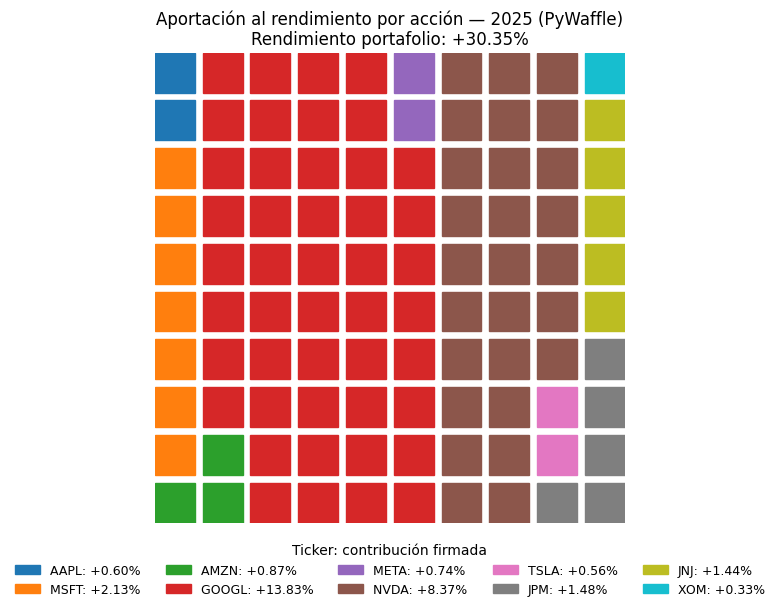

In [9]:
weights_pct = {
    "AAPL": 5, "MSFT": 13, "AMZN": 18, "GOOGL": 21, "META": 7,
    "NVDA": 24, "TSLA": 3, "JPM": 4, "JNJ": 3, "XOM": 2
}

TICKER_COLORS = {
    "AAPL": "#1f77b4",
    "MSFT": "#ff7f0e",
    "AMZN": "#2ca02c",
    "GOOGL":"#d62728",
    "META": "#9467bd",
    "NVDA": "#8c564b",
    "TSLA": "#e377c2",
    "JPM":  "#7f7f7f",
    "JNJ":  "#bcbd22",
    "XOM":  "#17becf",
}

TOTAL_TILES = 100  # tamaño del waffle (10x10)

prices = df.copy()
prices["DATE"] = pd.to_datetime(prices["DATE"], errors="coerce")
prices = prices.sort_values("DATE")

# Ventana 2025
start_2025 = pd.Timestamp("2025-01-01")
end_2025   = pd.Timestamp("2025-12-31")
mask_2025 = (prices["DATE"] >= start_2025) & (prices["DATE"] <= end_2025)
p25 = prices.loc[mask_2025].reset_index(drop=True)

# Retornos por acción (YTD 2025) usando Adj Close
rets_2025, present = {}, []
for tk in weights_pct.keys():
    col = f"ADJ_CLOSE_{tk}"
    s = p25[col].dropna()
    r = s.iloc[-1] / s.iloc[0] - 1.0
    rets_2025[tk] = float(r)
    present.append(tk)

# Pesos normalizados (si faltó alguno, re-normaliza con los presentes)
w = np.array([weights_pct[tk] for tk in present], dtype=float)
w = w / w.sum()

# Contribución al rendimiento 2025: c_i = w_i * r_i
r = np.array([rets_2025[tk] for tk in present], dtype=float)
contrib = dict(zip(present, w * r))
port_ret_2025 = float(sum(contrib.values()))
magnitudes = np.abs(np.array([contrib[tk] for tk in present], dtype=float))
total_mag = magnitudes.sum()

proportions = magnitudes / total_mag * TOTAL_TILES
tiles_floor = np.floor(proportions).astype(int)
remainders = proportions - tiles_floor
missing = int(TOTAL_TILES - tiles_floor.sum())
order = np.argsort(-remainders)
tiles = tiles_floor.copy()
for i in range(missing):
    tiles[order[i]] += 1

mask_pos = tiles > 0
present_arr = np.array(present)[mask_pos]
tiles = tiles[mask_pos]
colors = [TICKER_COLORS.get(tk, "#999999") for tk in present_arr]
labels = [f"{tk}: {contrib[tk]:+,.2%}" for tk in present_arr]
values_dict = {lab: int(n) for lab, n in zip(labels, tiles)}

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=values_dict,
    colors=colors,
    block_arranging_style="snake",
    starting_location="NW",
    figsize=(9, 6),
    legend={
        "loc": "lower center",
        "bbox_to_anchor": (0.5, -0.18),
        "ncol": 5,
        "frameon": False,
        "title": "Ticker: contribución firmada",
        "fontsize": 9
    },
)

plt.title(
    "Aportación al rendimiento por acción — 2025 (PyWaffle)\n"
    f"Rendimiento portafolio: {port_ret_2025:+.2%}"
)
plt.subplots_adjust(bottom=0.30)
plt.show()

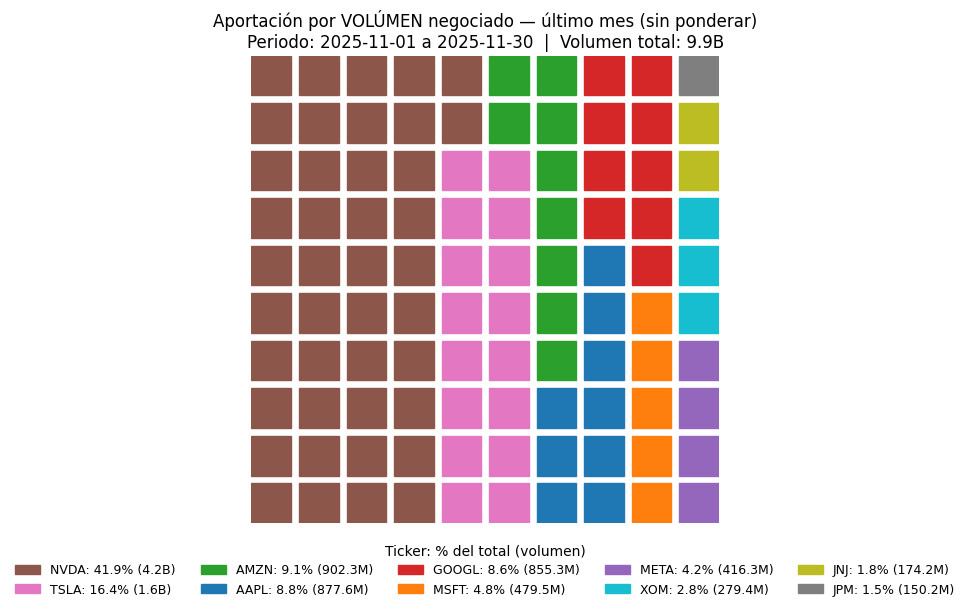

In [10]:
TOTAL_TILES = 100  # tamaño del waffle (10x10)

TICKER_COLORS = {
    "AAPL": "#1f77b4",
    "MSFT": "#ff7f0e",
    "AMZN": "#2ca02c",
    "GOOGL":"#d62728",
    "META": "#9467bd",
    "NVDA": "#8c564b",
    "TSLA": "#e377c2", 
    "JPM":  "#7f7f7f",
    "JNJ":  "#bcbd22",
    "XOM":  "#17becf",
}

def fmt_vol(n: float) -> str:
    """Formatea volúmenes a K/M/B con 1 decimal."""
    n = float(n)
    if n >= 1e9:
        return f"{n/1e9:.1f}B"
    if n >= 1e6:
        return f"{n/1e6:.1f}M"
    if n >= 1e3:
        return f"{n/1e3:.1f}K"
    return f"{n:.0f}"

vol_cols = [c for c in df.columns if (c.startswith("VOLUME_") and "GSPC" not in c)]

data = df.copy()
data["DATE"] = pd.to_datetime(data["DATE"], errors="coerce")
data = data.sort_values("DATE")

last_date = data["DATE"].dropna().max().normalize()
this_month_start = last_date.replace(day=1)
prev_month_end = this_month_start - pd.Timedelta(days=1)
prev_month_start = prev_month_end.replace(day=1)

mask = (data["DATE"] >= prev_month_start) & (data["DATE"] <= prev_month_end)
month_df = data.loc[mask, vol_cols].copy()

volumes = month_df.sum(axis=0, skipna=True)
tickers = [c.replace("VOLUME_", "") for c in volumes.index]
vol_dict = dict(zip(tickers, volumes.values))
vol_dict = {tk: v for tk, v in vol_dict.items() if v > 0}

tickers_sorted = sorted(vol_dict.keys(), key=lambda k: vol_dict[k], reverse=True)
vals_sorted = np.array([vol_dict[k] for k in tickers_sorted], dtype=float)
total_vol = float(vals_sorted.sum())

proportions = vals_sorted / total_vol * TOTAL_TILES
tiles_floor = np.floor(proportions).astype(int)
remainders = proportions - tiles_floor
missing = int(TOTAL_TILES - tiles_floor.sum())
order = np.argsort(-remainders)
tiles = tiles_floor.copy()
for i in range(missing):
    tiles[order[i]] += 1

mask_pos = tiles > 0
tickers_plot = np.array(tickers_sorted)[mask_pos]
tiles = tiles[mask_pos]
colors = [TICKER_COLORS.get(tk, "#999999") for tk in tickers_plot]

labels = [
    f"{tk}: {vol_dict[tk]/total_vol:.1%} ({fmt_vol(vol_dict[tk])})"
    for tk in tickers_plot
]

values_dict = {lab: int(n) for lab, n in zip(labels, tiles)}

title_main = "Aportación por VOLÚMEN negociado — último mes (sin ponderar)"
subtitle = f"Periodo: {prev_month_start.date()} a {prev_month_end.date()}  |  Volumen total: {fmt_vol(total_vol)}"

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=values_dict,
    colors=colors,
    block_arranging_style="snake",
    starting_location="NW",
    figsize=(9, 6),
    legend={
        "loc": "lower center",
        "bbox_to_anchor": (0.5, -0.18),
        "ncol": 5,
        "frameon": False,
        "title": "Ticker: % del total (volumen)",
        "fontsize": 9,
    },
)

plt.title(f"{title_main}\n{subtitle}")
plt.subplots_adjust(bottom=0.30)
plt.show()


#### Grouped Stacked barchar

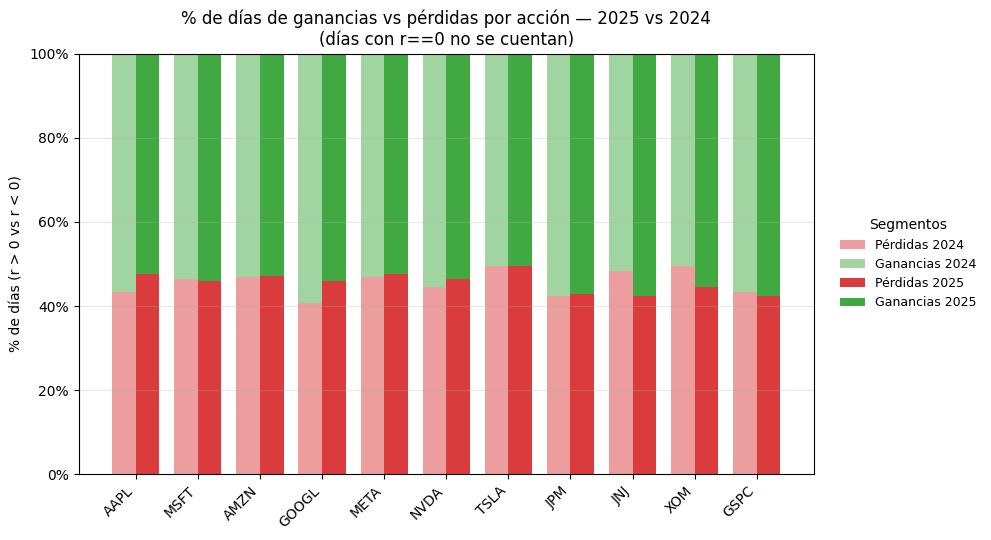

In [11]:
price_cols = [c for c in df.columns if c.startswith("ADJ_CLOSE_")]

dx = df.copy()
dx["DATE"] = pd.to_datetime(dx["DATE"], errors="coerce")
dx = dx.sort_values("DATE")

end_date = dx["DATE"].max()
yr_curr  = int(end_date.year)
yr_prev  = yr_curr - 1

rets = dx[["DATE"] + price_cols].copy()
rets[price_cols] = rets[price_cols].pct_change()
tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]
gain_curr, loss_curr, gain_prev, loss_prev = [], [], [], []

for col in price_cols:
    r = rets[["DATE", col]].dropna()
    rc = r[r["DATE"].dt.year == yr_curr][col]
    rp = r[r["DATE"].dt.year == yr_prev][col]

    gain_curr.append(int((rc > 0).sum()))
    loss_curr.append(int((rc < 0).sum()))
    gain_prev.append(int((rp > 0).sum()))
    loss_prev.append(int((rp < 0).sum()))

gain_curr = np.array(gain_curr, dtype=int)
loss_curr = np.array(loss_curr, dtype=int)
gain_prev = np.array(gain_prev, dtype=int)
loss_prev = np.array(loss_prev, dtype=int)

tot_curr = gain_curr + loss_curr
tot_prev = gain_prev + loss_prev

tot_curr = np.where(tot_curr == 0, 1, tot_curr)
tot_prev = np.where(tot_prev == 0, 1, tot_prev)
gain_curr_pct = gain_curr / tot_curr
loss_curr_pct = loss_curr / tot_curr
gain_prev_pct = gain_prev / tot_prev
loss_prev_pct = loss_prev / tot_prev


# https://htmlcolorcodes.com/
x = np.arange(len(tickers))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, loss_prev_pct, width=w, color="#d62728", alpha=0.45, label=f"Pérdidas {yr_prev}")
ax.bar(x - w/2, gain_prev_pct, width=w, bottom=loss_prev_pct, color="#2ca02c", alpha=0.45, label=f"Ganancias {yr_prev}")
ax.bar(x + w/2, loss_curr_pct, width=w, color="#d62728", alpha=0.9,  label=f"Pérdidas {yr_curr}")
ax.bar(x + w/2, gain_curr_pct, width=w, bottom=loss_curr_pct, color="#2ca02c", alpha=0.9,  label=f"Ganancias {yr_curr}")
ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation=45, ha="right")
ax.set_ylabel("% de días (r > 0 vs r < 0)")
ax.set_title(f"% de días de ganancias vs pérdidas por acción — {yr_curr} vs {yr_prev}\n"
             "(días con r==0 no se cuentan)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)

ax.legend(
    title="Segmentos",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)
plt.subplots_adjust(right=0.80)
fig.tight_layout()
plt.show()

#### Bubblechars

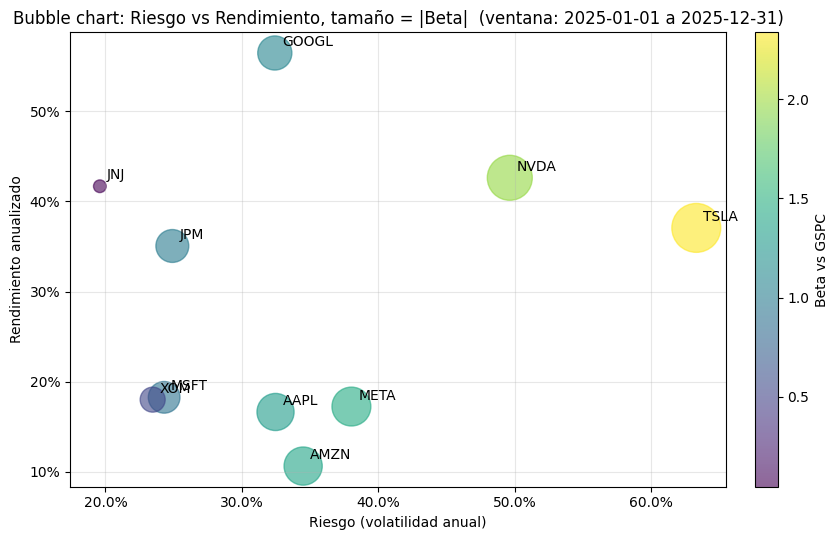

In [12]:
price_cols = [c for c in df.columns if "ADJ_CLOSE_" in c and c != "ADJ_CLOSE_GSPC"]

dx = df.copy()
dx["DATE"] = pd.to_datetime(dx["DATE"], errors="coerce")
dx = dx.sort_values("DATE")

end = dx["DATE"].max()
start = end - pd.DateOffset(years=1) + pd.DateOffset(days=1)

sub = dx.loc[(dx["DATE"] > start) & (dx["DATE"] <= end), ["DATE"] + price_cols + ["ADJ_CLOSE_GSPC"]]
sub = sub.dropna(how="all")

R = sub.set_index("DATE").pct_change().dropna(how="any")

mkt_col = "ADJ_CLOSE_GSPC"
tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]

rows = []
for col in price_cols:
    pair = R[[col, mkt_col]].dropna()
    mu_ann = pair[col].mean() * 252.0
    sig_ann = pair[col].std(ddof=1) * np.sqrt(252.0)
    cov = pair.cov()
    beta = cov.loc[col, mkt_col] / cov.loc[mkt_col, mkt_col]  # beta vs mercado
    rows.append({"TICKER": col.replace("ADJ_CLOSE_", ""), "MU": mu_ann, "SIGMA": sig_ann, "BETA": beta})

metrics = pd.DataFrame(rows)

abs_beta = metrics["BETA"].abs().values
median_abs = np.median(abs_beta) if np.isfinite(abs_beta).any() else 1.0
scale = 600.0
sizes = scale * (abs_beta / (median_abs if median_abs > 0 else 1.0)) + 60.0  # tamaño mínimo

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(metrics["SIGMA"], metrics["MU"], s=sizes, c=metrics["BETA"], alpha=0.6)

for _, r in metrics.iterrows():
    ax.annotate(r["TICKER"], (r["SIGMA"], r["MU"]), xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Riesgo (volatilidad anual)")
ax.set_ylabel("Rendimiento anualizado")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Beta vs GSPC")

ax.set_title(f"Bubble chart: Riesgo vs Rendimiento, tamaño = |Beta|  (ventana: {start.date()} a {end.date()})")
fig.tight_layout()
plt.show()

#### Scatterplots

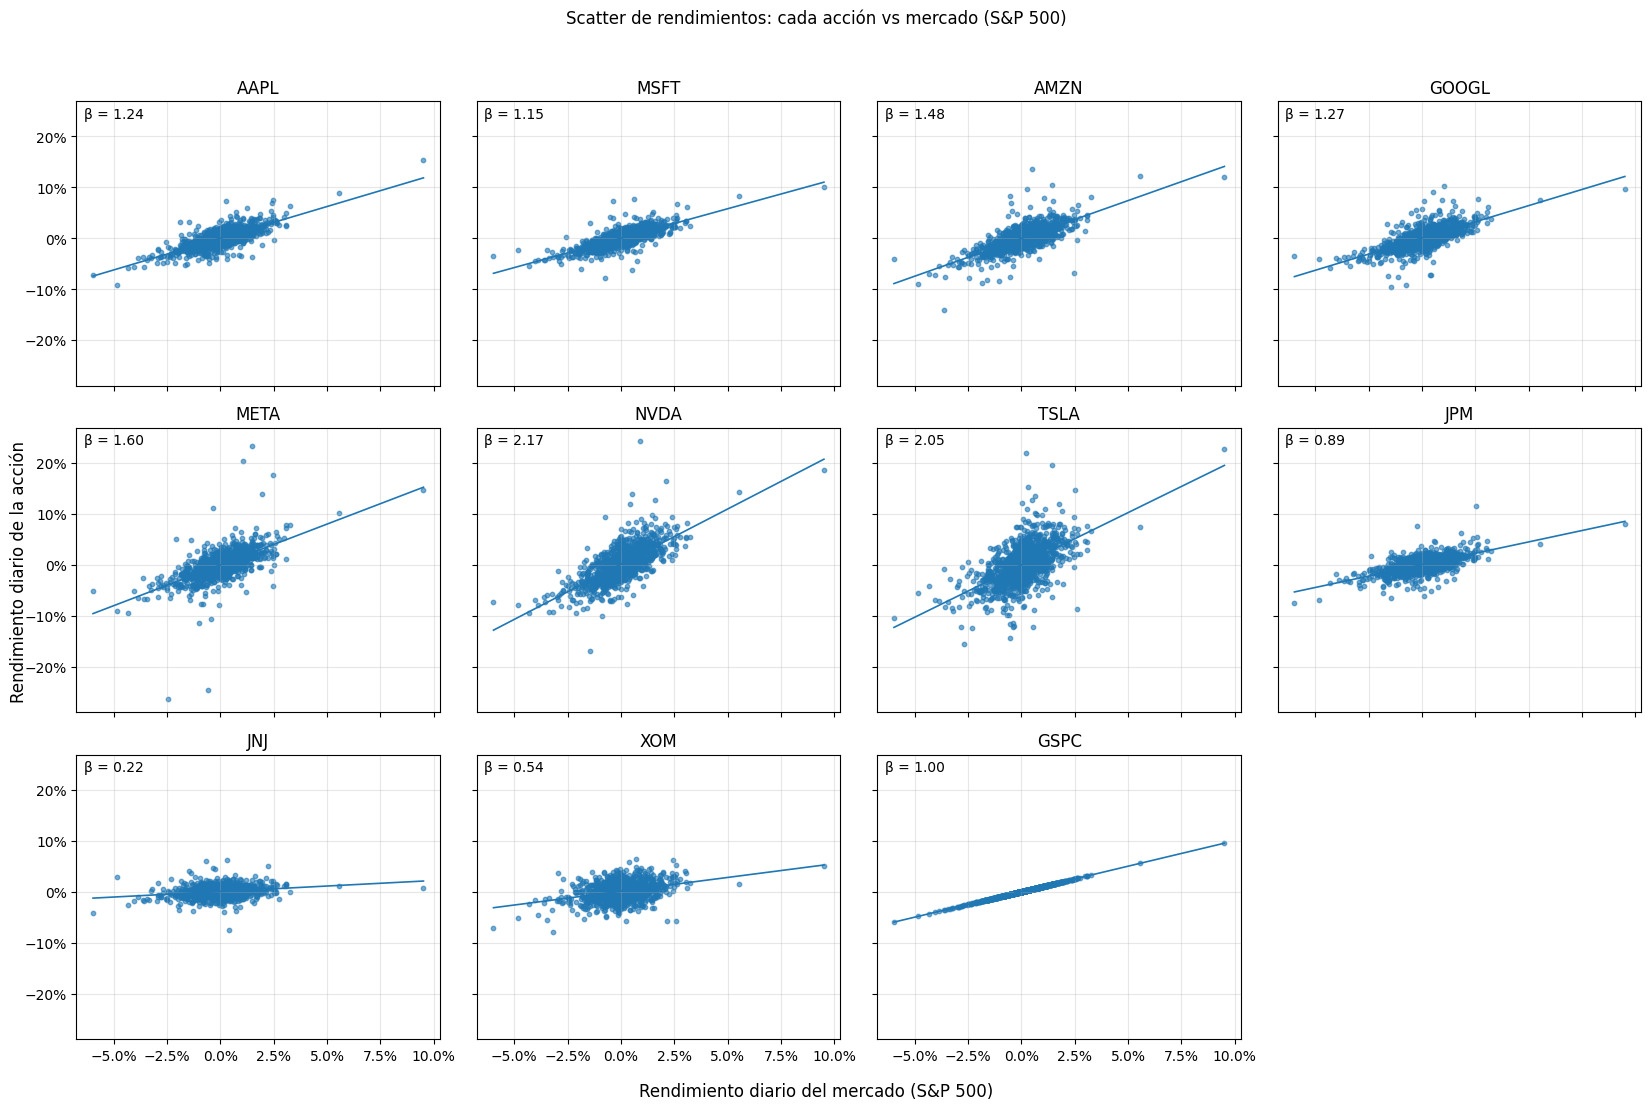

In [13]:
# Crea una lista con todas las columnas cuyo nombre empieza con "ADJ_CLOSE_"
# pero excluye específicamente la columna "ADJ_CLOSE_MXX"
price_cols = [c for c in df.columns if c.startswith("ADJ_CLOSE_") and c != "ADJ_CLOSE_MXX"]

# Hace una copia del DataFrame original para no modificarlo directamente
dx = df.copy()

# Convierte la columna DATE a formato fecha; si algún valor no se puede convertir, lo pone como NaT
dx["DATE"] = pd.to_datetime(dx["DATE"], errors="coerce")

# Ordena el DataFrame por fecha de menor a mayor
dx = dx.sort_values("DATE")

# Obtiene la fecha mínima de la serie y la normaliza quitando hora/minuto/segundo
start = dx["DATE"].min().normalize()

# Obtiene la fecha máxima de la serie y la normaliza quitando hora/minuto/segundo
end   = dx["DATE"].max().normalize()


# Hace otra copia del DataFrame ya ordenado, ahora para trabajar con rendimientos
rets = dx.copy()

# Reemplaza los precios de las columnas seleccionadas por su cambio porcentual respecto al día anterior
rets[price_cols] = rets[price_cols].pct_change()

# Elimina filas con valores faltantes, típicamente la primera fila generada por pct_change()
rets = rets.dropna()

# Guarda la serie de rendimientos del mercado (S&P 500) como variable de referencia
market = rets["ADJ_CLOSE_GSPC"]

# Crea una lista de tickers quitando el prefijo "ADJ_CLOSE_" de cada nombre de columna
tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]

# Cuenta cuántas series/activos se van a graficar
n = len(price_cols)

# Si hay 8 o más gráficos usa 4 columnas; si no, usa 3 columnas
ncols = 4 if n >= 8 else 3

# Calcula cuántas filas se necesitan para acomodar todos los subgráficos
nrows = math.ceil(n / ncols)

# Crea la figura y una cuadrícula de subgráficos compartiendo escalas en X y Y
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.6*nrows), sharex=True, sharey=True)

# Asegura que axes sea un arreglo unidimensional para poder recorrerlo fácilmente
axes = np.atleast_1d(axes).ravel()

# Recorre cada columna de precios/rendimientos junto con su índice
for i, col in enumerate(price_cols):

    # Selecciona el subgráfico que corresponde a la acción actual
    ax = axes[i]

    # Toma como variable Y los rendimientos de la acción actual
    y = rets[col]

    # Toma como variable X los rendimientos del mercado
    x = market

    # Crea una máscara booleana para conservar solo filas donde X y Y no son nulos
    mask = x.notna() & y.notna()

    # Aplica la máscara para quedarte solo con observaciones válidas
    x = x[mask]; y = y[mask]

    # Dibuja el scatter plot de la acción vs el mercado
    ax.scatter(x, y, s=10, alpha=0.6)

    # Si hay al menos 2 observaciones, ajusta una regresión lineal
    if len(x) >= 2:

        # Ajusta una recta y = slope*x + intercept
        # slope se interpreta como beta de la acción respecto al mercado
        slope, intercept = np.polyfit(x.values, y.values, 1)

        # Genera 100 puntos entre el mínimo y el máximo de X para dibujar la línea suavemente
        xline = np.linspace(x.min(), x.max(), 100)

        # Dibuja la recta de regresión sobre el scatter
        ax.plot(xline, slope * xline + intercept, linewidth=1.2)

        # Calcula los valores estimados por la recta para los X observados
        yhat = slope * x + intercept

        # Calcula la suma de residuos al cuadrado
        ss_res = np.sum((y - yhat) ** 2)

        # Calcula la suma total de cuadrados respecto a la media de Y
        ss_tot = np.sum((y - y.mean()) ** 2)

        # Calcula el R^2; si Y no tiene variación, devuelve NaN
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

        # Escribe la beta estimada dentro del gráfico, en la esquina superior izquierda
        ax.text(0.02, 0.98, f"β = {slope:.2f}", transform=ax.transAxes, va="top", ha="left")

    # Pone como título del subgráfico el ticker, quitando el prefijo "ADJ_CLOSE_"
    ax.set_title(col.replace("ADJ_CLOSE_", ""))

# Recorre los ejes que sobraron en la cuadrícula, si es que hay más ejes que gráficos
for k in range(n, len(axes)):

    # Oculta los ejes sobrantes para que no aparezcan vacíos
    axes[k].set_visible(False)

# Recorre únicamente los ejes que sí se usaron
for ax in axes[:n]:

    # Formatea el eje X como porcentaje, interpretando 1.0 como 100%
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # Formatea el eje Y como porcentaje, interpretando 1.0 como 100%
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # Agrega una cuadrícula tenue para facilitar la lectura
    ax.grid(True, alpha=0.3)

# Agrega un título general a toda la figura
fig.suptitle("Scatter de rendimientos: cada acción vs mercado (S&P 500)", y=1.02, fontsize=12)

# Agrega una etiqueta general al eje X de toda la figura
fig.supxlabel("Rendimiento diario del mercado (S&P 500)")

# Agrega una etiqueta general al eje Y de toda la figura
fig.supylabel("Rendimiento diario de la acción")

# Ajusta automáticamente espacios y márgenes para que no se encimen elementos
fig.tight_layout()

# Muestra la figura final en pantalla
plt.show()

#### Extra

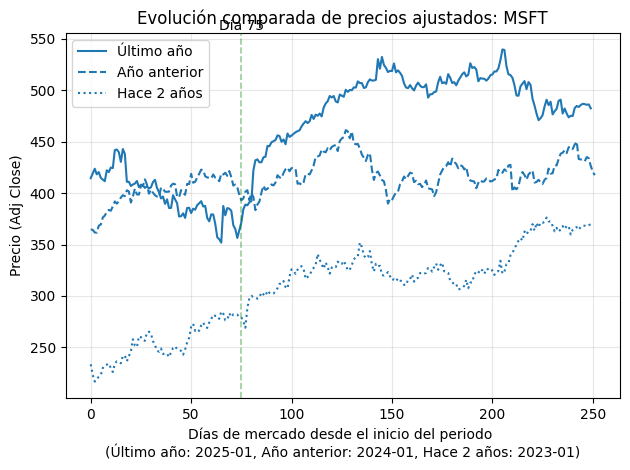

In [20]:
# Actividad: Evolución del valor de las acciones respecto al año anterior
# (las líneas punteadas son el año anterior)
# Marca de posible fenómeno estacional

ticker = "MSFT"
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
if "DATE" not in prices.columns:
    raise ValueError("El DataFrame debe tener la columna DATE.")
if col not in prices.columns:
    disponibles = ", ".join(sorted([c.replace("ADJ_CLOSE_", "") for c in prices.columns if c.startswith("ADJ_CLOSE_")]))
    raise ValueError(f"Ticker no encontrado: {ticker}. Disponibles: {disponibles}")

prices["DATE"] = pd.to_datetime(prices["DATE"], errors="coerce")
s = prices[["DATE", col]].dropna().sort_values("DATE")

end = s["DATE"].max()
start_1 = end - pd.DateOffset(years=1) + pd.DateOffset(days=1)
start_2 = end - pd.DateOffset(years=2)
start_3 = end - pd.DateOffset(years=3)

# Ventanas (datos y fechas reales de inicio por ventana)
mask0 = (s["DATE"] > start_1) & (s["DATE"] <= end)
mask1 = (s["DATE"] > start_2) & (s["DATE"] <= start_1)
mask2 = (s["DATE"] > start_3) & (s["DATE"] <= start_2)

y0 = s.loc[mask0, col].reset_index(drop=True)
y1 = s.loc[mask1, col].reset_index(drop=True)
y2 = s.loc[mask2, col].reset_index(drop=True)

d0 = s.loc[mask0, "DATE"].reset_index(drop=True)
d1 = s.loc[mask1, "DATE"].reset_index(drop=True)
d2 = s.loc[mask2, "DATE"].reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(len(y0)), y0.values, linestyle="-",  color="C0", linewidth=1.5, label="Último año")
plt.plot(range(len(y1)), y1.values, linestyle="--", color="C0", linewidth=1.5, label="Año anterior")
plt.plot(range(len(y2)), y2.values, linestyle=":",  color="C0", linewidth=1.5, label="Hace 2 años")

lbl0 = d0.iloc[0].strftime("%Y-%m") if len(d0) else "N/A"
lbl1 = d1.iloc[0].strftime("%Y-%m") if len(d1) else "N/A"
lbl2 = d2.iloc[0].strftime("%Y-%m") if len(d2) else "N/A"
plt.xlabel(f"Días de mercado desde el inicio del periodo \n"
           f"(Último año: {lbl0}, Año anterior: {lbl1}, Hace 2 años: {lbl2})")

plt.title(f"Evolución comparada de precios ajustados: {ticker}")
plt.ylabel("Precio (Adj Close)")
plt.grid(True, alpha=0.3)
plt.legend()

x_dia = 75
plt.axvline(x=x_dia, linestyle="--", color="green", linewidth=1.2, alpha=0.4, zorder=3)
ax = plt.gca()
ylim_top = ax.get_ylim()[1]
plt.text(x_dia, ylim_top, "Día 75", ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [15]:
# =========================
# BASE COMUN
# =========================

# Hace una copia del DataFrame original para trabajar sin modificar df directamente
prices = df.copy()

# Convierte la columna DATE a tipo fecha; si algún valor no puede convertirse, lo cambia a NaT
prices["DATE"] = pd.to_datetime(prices["DATE"], errors="coerce")

# Construye una lista con todas las columnas cuyo nombre empieza con "ADJ_CLOSE_"
# es decir, columnas de precios ajustados
price_cols = [c for c in prices.columns if c.startswith("ADJ_CLOSE_")]

# Crea un nuevo DataFrame llamado px que:
# 1) conserva solo DATE y las columnas de precios
# 2) ordena por fecha
# 3) usa DATE como índice
# 4) hace una copia final del resultado
px = (
    prices[["DATE"] + price_cols]
    .sort_values("DATE")
    .set_index("DATE")
    .copy()
)

# Guarda la fecha más reciente disponible en el índice de px
as_of = px.index.max()

# Define una función que recibe un ticker y devuelve el nombre exacto
# de la columna de precios ajustados correspondiente dentro de px
def get_price_col(ticker):

    # Construye el nombre esperado de la columna usando el ticker sanitizado
    # por ejemplo, "AAPL" -> "ADJ_CLOSE_AAPL"
    col = f"ADJ_CLOSE_{sanitize_col(ticker)}"

    # Si esa columna no existe en px, entra a esta validación
    if col not in px.columns:

        # Genera un texto con todos los tickers disponibles, quitando el prefijo "ADJ_CLOSE_"
        disponibles = ", ".join([c.replace("ADJ_CLOSE_", "") for c in px.columns])

        # Lanza un error indicando que el ticker no fue encontrado
        # y muestra además cuáles sí están disponibles
        raise ValueError(f"Ticker {ticker} no encontrado. Disponibles: {disponibles}")

    # Si la columna sí existe, la devuelve
    return col

# Define una función para calcular el rendimiento de una serie de precios
# Puede calcularlo de dos formas:
# 1) hacia atrás por número de periodos
# 2) desde una fecha inicial específica
def period_return(series, periods=None, start_date=None):

    # Elimina valores faltantes de la serie para evitar problemas en el cálculo
    s = series.dropna()

    # Si después de quitar nulos la serie queda vacía, devuelve NaN
    if s.empty:
        return np.nan

    # Toma el valor final de la serie, es decir, el precio más reciente
    end_val = s.iloc[-1]

    # Si el usuario especificó una fecha inicial, usa esa lógica
    if start_date is not None:

        # Filtra la serie desde start_date en adelante
        s0 = s[s.index >= pd.Timestamp(start_date)]

        # Si no hay datos a partir de esa fecha, devuelve NaN
        if s0.empty:
            return np.nan

        # Toma como valor inicial el primer dato disponible desde esa fecha
        start_val = s0.iloc[0]

    # Si no se especificó fecha inicial, usa la lógica por número de periodos
    else:

        # Si periods no fue proporcionado, o no hay suficientes datos en la serie,
        # no se puede calcular el rendimiento y devuelve NaN
        if periods is None or len(s) <= periods:
            return np.nan

        # Toma como valor inicial el precio de hace "periods" observaciones
        # Se usa periods + 1 porque el último valor es el final y queremos ir hacia atrás
        start_val = s.iloc[-(periods + 1)]

    # Si el valor inicial es nulo o es 0, no se puede dividir entre él
    # entonces devuelve NaN para evitar errores o infinitos
    if pd.isna(start_val) or start_val == 0:
        return np.nan

    # Calcula el rendimiento simple:
    # (precio final / precio inicial) - 1
    return (end_val / start_val) - 1

### Table

In [16]:
# Crea una lista vacía donde se irán guardando los resultados de cada acción
rows = []

# Construye la fecha de inicio del año actual usando el año de as_of
# Por ejemplo, si as_of es 2025-08-14, year_start será 2025-01-01
year_start = pd.Timestamp(as_of.year, 1, 1)

# Calcula la fecha de hace un año respecto a as_of
# Por ejemplo, si as_of es 2025-08-14, one_year_ago será 2024-08-14
one_year_ago = as_of - pd.DateOffset(years=1)

# Recorre cada columna de precios ajustados
for col in price_cols:

    # Obtiene el ticker quitando el prefijo "ADJ_CLOSE_"
    # Ejemplo: "ADJ_CLOSE_AAPL" -> "AAPL"
    ticker = col.replace("ADJ_CLOSE_", "")

    # Toma la serie de precios de esa acción y elimina valores faltantes
    s = px[col].dropna()

    # Agrega a la lista rows un diccionario con los indicadores calculados para esa acción
    rows.append({
        # Guarda el ticker
        "Ticker": ticker,

        # Guarda el último precio disponible
        # Si la serie está vacía, guarda NaN
        "Last Price": s.iloc[-1] if not s.empty else np.nan,

        # Calcula el rendimiento de la última semana
        # Aquí se asume 5 días hábiles de mercado
        "Last Week": period_return(s, periods=5),

        # Calcula el rendimiento del último mes
        # Aquí se asume 21 días hábiles de mercado
        "Last Month": period_return(s, periods=21),

        # Calcula el rendimiento acumulado en el año (Year To Date)
        # desde el 1 de enero hasta la fecha as_of
        "YTD": period_return(s, start_date=year_start),

        # Calcula el rendimiento de último año (Year over Year)
        # desde la fecha equivalente de hace un año hasta as_of
        "YoY": period_return(s, start_date=one_year_ago)
    })

# Convierte la lista de diccionarios en un DataFrame
# Cada diccionario se vuelve una fila
ret_table = pd.DataFrame(rows)

# Ordena la tabla de mayor a menor usando primero YTD,
# luego Last Month y luego Last Week como criterios de desempate
ret_table = ret_table.sort_values(
    by=["YTD", "Last Month", "Last Week"],
    ascending=False
).reset_index(drop=True)

# Inserta una columna Rank al inicio de la tabla con valores 1, 2, 3, ...
# según el orden actual de la tabla
ret_table.insert(0, "Rank", np.arange(1, len(ret_table) + 1))


# Define una función que aplicará estilo visual a una columna
# resaltando ganadores en verde y perdedores en rojo
def winners_losers_style(col):

    # Convierte la columna a valores numéricos
    # si algo no puede convertirse, lo transforma en NaN
    vals = pd.to_numeric(col, errors="coerce").values

    # Verifica si existe al menos un valor positivo en la columna
    has_pos = np.any(vals > 0)

    # Verifica si existe al menos un valor negativo en la columna
    has_neg = np.any(vals < 0)

    # Si hay positivos, obtiene el mayor valor positivo
    # si no hay, deja NaN
    pos_max = np.nanmax(np.where(vals > 0, vals, np.nan)) if has_pos else np.nan

    # Si hay negativos, obtiene el menor valor negativo
    # es decir, el más negativo de todos
    # si no hay, deja NaN
    neg_min = np.nanmin(np.where(vals < 0, vals, np.nan)) if has_neg else np.nan

    # Crea una lista vacía donde se guardará el estilo CSS de cada celda
    styles = []

    # Recorre cada valor de la columna
    for v in vals:

        # Si el valor es NaN, pinta la celda en gris claro con texto gris
        if pd.isna(v):
            styles.append("background-color: #f5f5f5; color: #999999;")

        # Si el valor es positivo, pinta la celda en verde
        elif v > 0:

            # Calcula una intensidad proporcional al tamaño del valor
            # valores positivos más altos tendrán verde más intenso
            intensity = 0.20 + 0.75 * (v / pos_max if pos_max > 0 else 0)

            # Agrega el estilo CSS para celda positiva
            styles.append(
                f"background-color: rgba(46, 125, 50, {intensity:.2f}); "
                "color: white; font-weight: 600;"
            )

        # Si el valor es negativo, pinta la celda en rojo
        elif v < 0:

            # Calcula una intensidad proporcional al tamaño absoluto del valor negativo
            # valores más negativos tendrán rojo más intenso
            intensity = 0.20 + 0.75 * (abs(v) / abs(neg_min) if neg_min < 0 else 0)

            # Agrega el estilo CSS para celda negativa
            styles.append(
                f"background-color: rgba(198, 40, 40, {intensity:.2f}); "
                "color: white; font-weight: 600;"
            )

        # Si el valor es exactamente 0, lo pinta de gris neutro
        else:
            styles.append("background-color: #eeeeee; color: black; font-weight: 600;")

    # Devuelve la lista de estilos, uno por cada celda de la columna
    return styles


# Crea una versión estilizada del DataFrame ret_table
styled_ret_table = (
    ret_table.style

    # Define el formato visual de cada columna numérica
    .format({
        # Precio con separador de miles y 2 decimales
        "Last Price": "{:,.2f}",

        # Rendimientos con signo y formato porcentaje
        "Last Week": "{:+.2%}",
        "Last Month": "{:+.2%}",
        "YTD": "{:+.2%}",
        "YoY": "{:+.2%}"
    })

    # Aplica el estilo de ganadores/perdedores a la columna Last Week
    .apply(winners_losers_style, subset=["Last Week"])

    # Aplica el estilo de ganadores/perdedores a la columna Last Month
    .apply(winners_losers_style, subset=["Last Month"])

    # Aplica el estilo de ganadores/perdedores a la columna YTD
    .apply(winners_losers_style, subset=["YTD"])

    # Aplica el estilo de ganadores/perdedores a la columna YoY
    .apply(winners_losers_style, subset=["YoY"])

    # Hace negritas la columna Ticker
    .set_properties(subset=["Ticker"], **{"font-weight": "bold"})

    # Centra el contenido de la columna Rank
    .set_properties(subset=["Rank"], **{"text-align": "center"})

    # Aplica propiedades generales a toda la tabla
    .set_properties(**{
        # Borde gris claro en las celdas
        "border": "1px solid #d9d9d9",

        # Espaciado interno
        "padding": "6px",

        # Centra el texto
        "text-align": "center"
    })

    # Define estilos especiales para encabezados y caption
    .set_table_styles([
        {
            # Estilo para los encabezados de columna
            "selector": "th",
            "props": [
                ("background-color", "#111111"),  # fondo negro
                ("color", "white"),               # texto blanco
                ("font-weight", "bold"),          # texto en negrita
                ("text-align", "center")          # centrado
            ]
        },
        {
            # Estilo para el título/caption de la tabla
            "selector": "caption",
            "props": [
                ("caption-side", "top"),          # coloca el caption arriba
                ("font-size", "14px"),            # tamaño de letra
                ("font-weight", "bold")           # negrita
            ]
        }
    ])

    # Agrega un título a la tabla mostrando la fecha de corte
    .set_caption(f"Rendimientos por acción al {as_of.date()}")
)

# Muestra en pantalla la tabla estilizada
display(styled_ret_table)

,Rank,Ticker,Last Price,Last Week,Last Month,YTD,YoY
0,1,GOOGL,312.78,-0.43%,-0.54%,+65.88%,+65.99%
1,2,JNJ,205.86,+0.57%,+0.78%,+48.09%,+47.48%
2,3,JPM,320.77,-1.14%,+4.31%,+37.10%,+37.27%
3,4,NVDA,186.49,-1.43%,+3.66%,+34.88%,+38.92%
4,5,TSLA,449.72,-7.38%,+4.55%,+18.57%,+11.36%
5,6,GSPC,"6,845.50",-0.93%,+0.48%,+16.65%,+16.39%
6,7,MSFT,482.52,-0.66%,-0.64%,+16.39%,+15.58%
7,8,XOM,119.54,+0.77%,+3.18%,+16.26%,+15.98%
8,9,AAPL,271.61,-0.18%,-3.97%,+11.99%,+9.05%
9,10,META,659.53,-0.73%,+3.08%,+10.50%,+13.09%


### Slopegraph

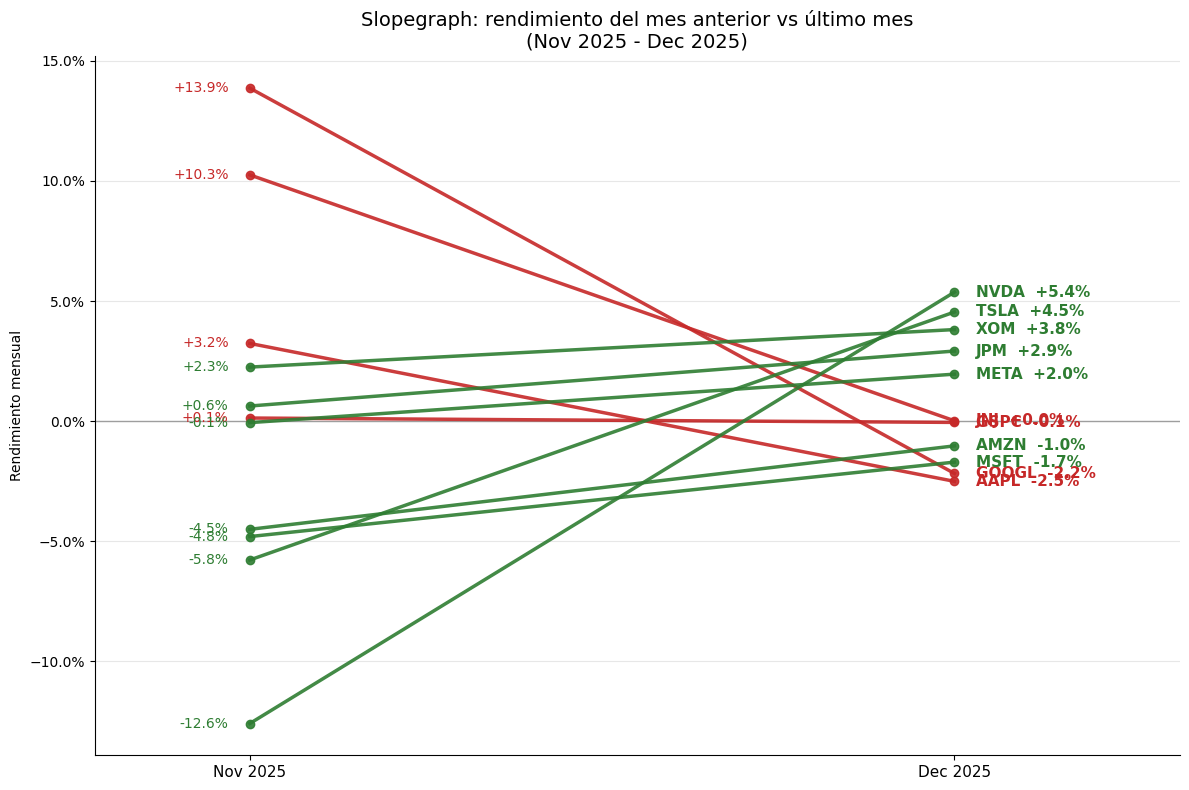

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick

# ==========================================
# SLOPEGRAPH:
# mes anterior vs último mes
# ==========================================

price_cols = [c for c in df.columns if c.startswith("ADJ_CLOSE_")]

# detectar columna fecha
dfx = df.copy()

if "DATE" in dfx.columns:
    date_col = "DATE"
elif "Date" in dfx.columns:
    date_col = "Date"
else:
    raise ValueError("No se encontró columna de fecha. Debe existir 'DATE' o 'Date'.")

dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")
dfx = dfx.sort_values(date_col).copy()

# dejar solo fecha + precios
px = dfx[[date_col] + price_cols].copy()
px = px.set_index(date_col)

# convertir a frecuencia mensual usando el último dato disponible de cada mes
monthly_px = px.resample("ME").last()

# calcular rendimientos mensuales
monthly_ret = monthly_px.pct_change()

# nos quedamos con los últimos 2 meses disponibles de rendimiento
monthly_ret = monthly_ret.dropna(how="all")

if len(monthly_ret) < 2:
    raise ValueError("No hay suficientes meses para comparar mes anterior vs último mes.")

last_two = monthly_ret.iloc[-2:].copy()

prev_month_date = last_two.index[0]
last_month_date = last_two.index[1]

rows = []
for col in price_cols:
    ticker = col.replace("ADJ_CLOSE_", "")
    r_prev = last_two.iloc[0][col]
    r_last = last_two.iloc[1][col]

    if pd.isna(r_prev) or pd.isna(r_last):
        continue

    rows.append({
        "Ticker": ticker,
        "PrevMonth": r_prev,
        "LastMonth": r_last,
        "Delta": r_last - r_prev
    })

res = pd.DataFrame(rows)

if res.empty:
    raise ValueError("No hay tickers con datos válidos en ambos meses.")

# ordenar por rendimiento del último mes
res = res.sort_values("LastMonth").reset_index(drop=True)

# ==========================================
# GRAFICO
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))

x0, x1 = 0, 1

# línea horizontal en 0%
ax.axhline(0, color="gray", linewidth=1, alpha=0.7)

for _, row in res.iterrows():
    ticker = row["Ticker"]
    y0 = row["PrevMonth"]
    y1 = row["LastMonth"]
    delta = row["Delta"]

    # color según mejora o empeora respecto al mes anterior
    if delta > 0:
        color = "#2e7d32"   # mejoró
    elif delta < 0:
        color = "#c62828"   # empeoró
    else:
        color = "#616161"   # sin cambio

    ax.plot(
        [x0, x1],
        [y0, y1],
        color=color,
        linewidth=2.5,
        marker="o",
        alpha=0.9
    )

    # etiqueta izquierda
    ax.text(
        x0 - 0.03,
        y0,
        f"{y0:+.1%}",
        ha="right",
        va="center",
        fontsize=10,
        color=color
    )

    # etiqueta derecha
    ax.text(
        x1 + 0.03,
        y1,
        f"{ticker}  {y1:+.1%}",
        ha="left",
        va="center",
        fontsize=11,
        color=color,
        fontweight="bold"
    )

ax.set_xlim(-0.22, 1.32)
ax.set_xticks([x0, x1])
ax.set_xticklabels(
    [
        prev_month_date.strftime("%b %Y"),
        last_month_date.strftime("%b %Y")
    ],
    fontsize=11
)

ax.set_ylabel("Rendimiento mensual")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title(
    f"Slopegraph: rendimiento del mes anterior vs último mes\n"
    f"({prev_month_date.strftime('%b %Y')} - {last_month_date.strftime('%b %Y')})",
    fontsize=14
)

ax.grid(axis="y", alpha=0.3)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
## cómo resolverías el empalme de etiquetas?

### Waterfall

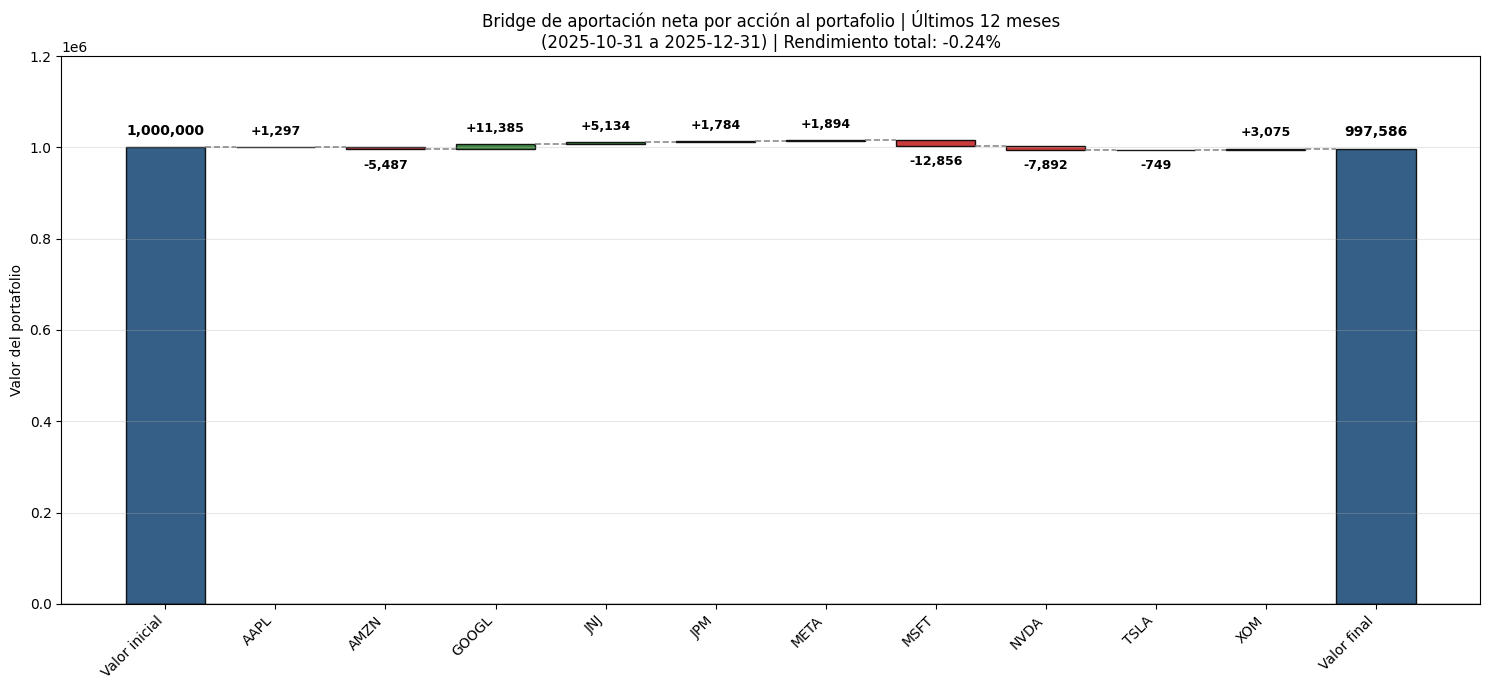

In [19]:
# =========================
# BRIDGE / WATERFALL:
# aportación neta de cada acción al valor del portafolio
# en los últimos 12 meses
# =========================

weights = {
    "AAPL": 0.20, "MSFT": 0.20, "AMZN": 0.10, "GOOGL": 0.10, "META": 0.10,
    "NVDA": 0.10, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05
}

# Normaliza por si no suman exactamente 1
w = pd.Series(weights, dtype=float)
w = w / w.sum()

# Valor base del portafolio
portfolio_start_value = 1_000_000

# Ventana: últimos 12 meses desde la última fecha disponible
period_end = as_of
period_start = period_end - pd.DateOffset(months=2)

rows = []

for ticker, weight in w.items():
    col = get_price_col(ticker)
    s = px[col].dropna()

    # Serie del periodo de análisis
    s_12m = s[s.index >= period_start].copy()

    if len(s_12m) < 2:
        continue

    start_price = s_12m.iloc[0]
    end_price = s_12m.iloc[-1]

    if pd.isna(start_price) or start_price == 0:
        continue

    ret_12m = (end_price / start_price) - 1
    contribution_ret = weight * ret_12m
    contribution_value = portfolio_start_value * contribution_ret

    rows.append({
        "Ticker": ticker,
        "Weight": weight,
        "StartPrice": start_price,
        "EndPrice": end_price,
        "Return12M": ret_12m,
        "ContributionRet": contribution_ret,
        "ContributionValue": contribution_value
    })

contrib_df = pd.DataFrame(rows)

if contrib_df.empty:
    raise ValueError("No hay datos suficientes para construir el bridge de los últimos 12 meses.")

# Si quieres ordenar por aportación al valor:
contrib_df = contrib_df.sort_values("Ticker").reset_index(drop=True)

portfolio_return = contrib_df["ContributionRet"].sum()
portfolio_end_value = portfolio_start_value * (1 + portfolio_return)

# Límite superior del eje Y
y_max_ref = max(portfolio_start_value, portfolio_end_value)
y_max = y_max_ref * 1.20

# =========================
# CONSTRUIR ESTRUCTURA DEL WATERFALL
# =========================
wf_rows = []

# Barra inicial
wf_rows.append({
    "Step": "Valor inicial",
    "Value": portfolio_start_value,
    "Base": 0,
    "Type": "total"
})

running_total = portfolio_start_value

# Barras intermedias por acción
for _, row in contrib_df.iterrows():
    wf_rows.append({
        "Step": row["Ticker"],
        "Value": row["ContributionValue"],
        "Base": running_total,
        "Type": "change",
        "ContributionRet": row["ContributionRet"],
        "Return12M": row["Return12M"],
        "Weight": row["Weight"]
    })
    running_total += row["ContributionValue"]

# Barra final
wf_rows.append({
    "Step": "Valor final",
    "Value": running_total,
    "Base": 0,
    "Type": "total"
})

wf = pd.DataFrame(wf_rows)

# Colores
colors = []
for _, row in wf.iterrows():
    if row["Type"] == "total":
        colors.append("#1f4e79")
    else:
        colors.append("#2e7d32" if row["Value"] >= 0 else "#c62828")

x = np.arange(len(wf))
bar_width = 0.72

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(
    x,
    wf["Value"],
    bottom=wf["Base"],
    width=bar_width,
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# =========================
# LÍNEAS CONECTORAS
# =========================
for i in range(len(wf) - 1):
    current = wf.iloc[i]
    nxt = wf.iloc[i + 1]

    if current["Type"] == "total":
        y_current = current["Value"]
    else:
        y_current = current["Base"] + current["Value"]

    if nxt["Type"] == "total":
        y_next = nxt["Value"]
    else:
        y_next = nxt["Base"]

    ax.plot(
        [x[i] + bar_width / 2, x[i + 1] - bar_width / 2],
        [y_current, y_next],
        linestyle="--",
        linewidth=1.2,
        color="gray",
        alpha=0.9
    )

# =========================
# ETIQUETAS
# =========================
offset = max(abs(wf["Value"]).max(), abs(wf["Base"]).max()) * 0.02

for i, row in wf.iterrows():
    if row["Type"] == "total":
        y_top = row["Value"]
        label = f"{row['Value']:,.0f}"
        ax.text(
            x[i], y_top + offset, label,
            ha="center", va="bottom",
            fontweight="bold", fontsize=10
        )
    else:
        y_top = row["Base"] + row["Value"]
        label = f"{row['Value']:+,.0f}"

        if row["Value"] >= 0:
            ax.text(
                x[i], y_top + offset, label,
                ha="center", va="bottom",
                fontweight="bold", fontsize=9
            )
        else:
            ax.text(
                x[i], y_top - offset, label,
                ha="center", va="top",
                fontweight="bold", fontsize=9
            )

# =========================
# ETIQUETAS DEL EJE X
# =========================
xlabels = wf["Step"].tolist()

ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha="right")

ax.set_ylabel("Valor del portafolio")
ax.set_title(
    f"Bridge de aportación neta por acción al portafolio | Últimos 12 meses\n"
    f"({period_start.date()} a {period_end.date()}) | Rendimiento total: {portfolio_return:+.2%}"
)

# Aquí sí ya existe y_max y ax
ax.set_ylim(top=y_max)

ax.grid(axis="y", alpha=0.3)
ax.axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()